# Bitcoin Price Prediction: Classical Model Comparison

Testing different ML models for next-day Bitcoin return prediction and comparing their performance with directional accuracy and Sharpe ratio metrics for backtesting.

In [5]:
# imports

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor

## Load and prepare data

Same pipeline for all models: load data, create features, split 80/20 chronologically, standardize.

In [ ]:
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)

DATA_PATH = "../../data/bitcoin_price_Training.csv"
df = pd.read_csv(DATA_PATH)

df["Date"] = pd.to_datetime(df["Date"], format="%b %d, %Y", errors="coerce")
if df["Date"].isna().all():
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

df = df.sort_values("Date", ascending=True).reset_index(drop=True)


def clean_currency_series(s: pd.Series) -> pd.Series:
    cleaned = (
        s.astype(str)
        .str.replace(",", "", regex=False)
        .str.replace("-", "0", regex=False)
        .str.strip()
    )
    return pd.to_numeric(cleaned, errors="coerce")


for col in ["Volume", "Market Cap"]:
    if col in df.columns:
        df[col] = clean_currency_series(df[col])

df["Return_1d"] = df["Close"].pct_change()
df["Return_3d"] = df["Close"].pct_change(3)
sma_7 = df["Close"].rolling(window=7, min_periods=7).mean()
df["SMA_7_diff"] = (df["Close"] - sma_7) / sma_7
df["Volatility_7"] = df["Return_1d"].rolling(window=7, min_periods=7).std()

df["Next_Return"] = df["Return_1d"].shift(-1)
df["Next_Close"] = df["Close"].shift(-1)

df["Target_Direction"] = np.sign(df["Next_Return"])
df.loc[df["Target_Direction"] == 0, "Target_Direction"] = 1

feature_cols = ["Return_1d", "Return_3d", "SMA_7_diff", "Volatility_7"]
df = df.dropna(
    subset=feature_cols + ["Next_Return", "Next_Close", "Target_Direction"]
).reset_index(drop=True)

X = df[feature_cols]
y_ret = df["Next_Return"]
y_dir = df["Target_Direction"]

split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_ret_train, y_ret_test = y_ret.iloc[:split_idx], y_ret.iloc[split_idx:]
y_dir_train, y_dir_test = y_dir.iloc[:split_idx], y_dir.iloc[split_idx:]
test_df = df.iloc[split_idx:].copy()

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train.shape, X_test.shape, split_idx

((1238, 4), (310, 4), 1238)

## Evaluation metrics

- Directional accuracy: % correct on up/down calls
- RMSE: price reconstruction error
- Sharpe ratio: risk-adjusted return of sign-based strategy

### Rationale

To assess both the predictive power and the practical tradability of the models, we use three key metrics:

*   **Directional Accuracy**: Measures the ability to correctly predict price trend (Up/Down). This is critical for signal-based trading where the trend is often more important than the exact price.
*   **RMSE**: Quantifies the magnitude of price forecast errors. It penalizes large misses, ensuring the model's price predictions remain grounded during high volatility.
*   **Annualized Sharpe Ratio**: The primary metric for risk-adjusted performance. It determines if the model's returns are consistent or merely the result of excessive risk, allowing for direct comparison with a 'buy and hold' strategy.


In [6]:
def evaluate_model(model_name, predictions, test_df, is_classifier=False):
    """
    Unified metrics for classifiers (±1) vs regressors (continuous returns).
    Returns a dict with RMSE, Directional Accuracy (%), and annualized Sharpe.
    """
    close = test_df["Close"].to_numpy(dtype=float)
    actual_next_close = test_df["Next_Close"].to_numpy(dtype=float)
    actual_next_return = test_df["Next_Return"].to_numpy(dtype=float)

    pred = np.asarray(predictions, dtype=float)

    if is_classifier:
        predicted_direction = pred.astype(int)
        pred_price = close * (1.0 + predicted_direction * 0.01)
        rmse = float(np.sqrt(mean_squared_error(actual_next_close, pred_price)))
    else:
        predicted_direction = np.sign(pred)
        pred_price = close * (1.0 + pred)
        rmse = float(np.sqrt(mean_squared_error(actual_next_close, pred_price)))

    actual_dir = np.sign(actual_next_return)
    actual_dir = np.where(actual_dir == 0, 1, actual_dir)
    directional_accuracy = float(np.mean(predicted_direction == actual_dir) * 100.0)

    strategy_return = predicted_direction * actual_next_return
    std = np.std(strategy_return, ddof=1)
    if std > 0:
        annualized_sharpe = float(np.sqrt(365.0) * np.mean(strategy_return) / std)
    else:
        annualized_sharpe = float("nan")

    return {
        "Model": model_name,
        "RMSE": rmse,
        "Directional_Accuracy_%": directional_accuracy,
        "Annualized_Sharpe": annualized_sharpe,
    }

## Models tested

- Gaussian Naive Bayes
- Decision Tree
- Support Vector Regression
- Gradient Boosting

In [10]:
results_rows = []

# Gaussian Naive Bayes
gnb = GaussianNB()
gnb.fit(X_train_scaled, y_dir_train)
pred_gnb = gnb.predict(X_test_scaled)
results_rows.append(
    evaluate_model("GaussianNB (direction)", pred_gnb, test_df, is_classifier=True)
)

# Decision Tree
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train_scaled, y_dir_train)
pred_dt = dt.predict(X_test_scaled)
results_rows.append(
    evaluate_model("DecisionTree (max_depth=5)", pred_dt, test_df, is_classifier=True)
)

results_rows

[{'Model': 'GaussianNB (direction)',
  'RMSE': 70.34160697932926,
  'Directional_Accuracy_%': 40.64516129032258,
  'Annualized_Sharpe': -1.770675692131001},
 {'Model': 'DecisionTree (max_depth=5)',
  'RMSE': 70.4187820597801,
  'Directional_Accuracy_%': 57.41935483870968,
  'Annualized_Sharpe': 1.7194753330296864}]

In [11]:
# Support Vector Regression
svr = SVR(kernel="rbf", C=1.0)
svr.fit(X_train_scaled, y_ret_train)
pred_svr = svr.predict(X_test_scaled)
results_rows.append(
    evaluate_model("SVR (RBF, C=1.0)", pred_svr, test_df, is_classifier=False)
)

# Gradient Boosting
gbr = GradientBoostingRegressor(n_estimators=100, max_depth=3, random_state=42)
gbr.fit(X_train_scaled, y_ret_train)
pred_gbr = gbr.predict(X_test_scaled)
results_rows.append(
    evaluate_model("GradientBoostingRegressor", pred_gbr, test_df, is_classifier=False)
)

results_rows

[{'Model': 'GaussianNB (direction)',
  'RMSE': 70.34160697932926,
  'Directional_Accuracy_%': 40.64516129032258,
  'Annualized_Sharpe': -1.770675692131001},
 {'Model': 'DecisionTree (max_depth=5)',
  'RMSE': 70.4187820597801,
  'Directional_Accuracy_%': 57.41935483870968,
  'Annualized_Sharpe': 1.7194753330296864},
 {'Model': 'SVR (RBF, C=1.0)',
  'RMSE': 78.47563232236193,
  'Directional_Accuracy_%': 51.935483870967744,
  'Annualized_Sharpe': 0.713978737554818},
 {'Model': 'GradientBoostingRegressor',
  'RMSE': 68.86510261325489,
  'Directional_Accuracy_%': 52.903225806451616,
  'Annualized_Sharpe': 1.2195530133537986}]

In [12]:
comparison_df = pd.DataFrame(results_rows)
comparison_df = comparison_df.set_index("Model")
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
comparison_df

,RMSE,Directional_Accuracy_%,Annualized_Sharpe
Model,,,
GaussianNB (direction),70.3416,40.6452,-1.7707
DecisionTree (max_depth=5),70.4188,57.4194,1.7195
"SVR (RBF, C=1.0)",78.4756,51.9355,0.7140
GradientBoostingRegressor,68.8651,52.9032,1.2196


## Results visualisation

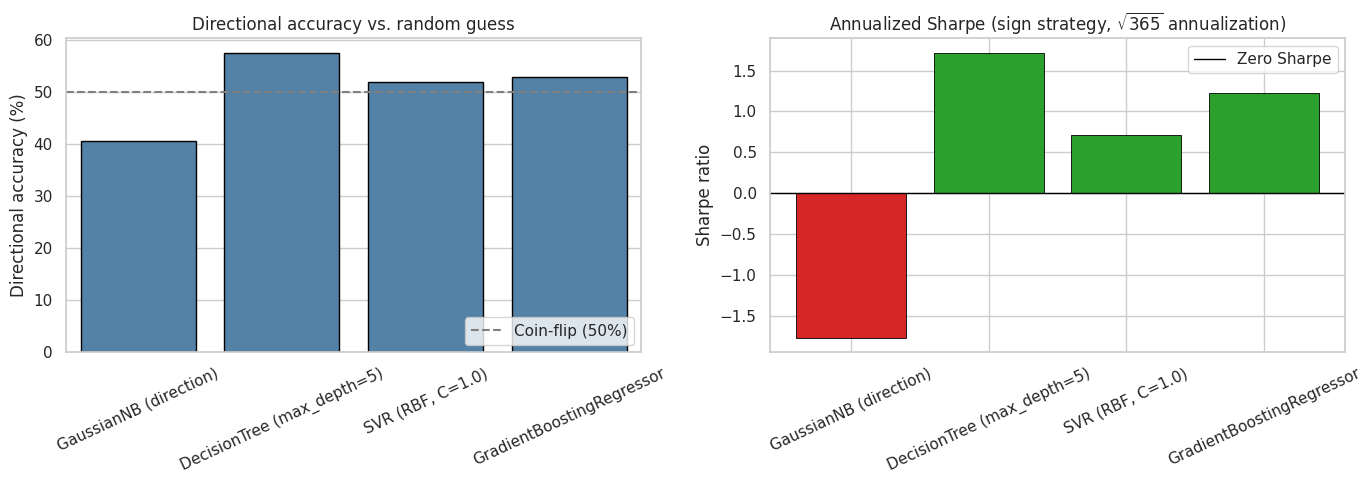

In [14]:
plot_df = comparison_df.reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax0 = axes[0]
sns.barplot(data=plot_df, x="Model", y="Directional_Accuracy_%", ax=ax0, color="steelblue", edgecolor="black")
ax0.axhline(50.0, color="gray", linestyle="--", linewidth=1.5, label="Coin-flip (50%)")
ax0.set_title("Directional accuracy vs. random guess")
ax0.set_xlabel("")
ax0.set_ylabel("Directional accuracy (%)")
ax0.tick_params(axis="x", rotation=25)
ax0.legend(loc="lower right")

ax1 = axes[1]
colors = ["#2ca02c" if s > 0 else "#d62728" for s in plot_df["Annualized_Sharpe"]]
bars = ax1.bar(plot_df["Model"], plot_df["Annualized_Sharpe"], color=colors, edgecolor="black", linewidth=0.6)
ax1.axhline(0.0, color="black", linestyle="-", linewidth=1.0, label="Zero Sharpe")
ax1.set_title(r"Annualized Sharpe (sign strategy, $\sqrt{365}$ annualization)")
ax1.set_xlabel("")
ax1.set_ylabel("Sharpe ratio")
ax1.tick_params(axis="x", rotation=25)
ax1.legend(loc="best")

plt.tight_layout()
plt.show()

## Results

Four classical machine learning models were evaluated for their ability to predict next-day Bitcoin price returns: Gaussian Naive Bayes, Decision Trees, Support Vector Regression (SVR), and Gradient Boosting. The results indicate that non-linear tree-based models significantly outperform the probabilistic baseline. 

*   **Top Performer:** The **Decision Tree** model ($max\_depth=5$) achieved the highest **directional accuracy of 57.42%** and a strong **annualized Sharpe ratio of 1.72**, making it the most effective model for a sign-based trading strategy.
*   **Regression Accuracy:** **Gradient Boosting** yielded the lowest **RMSE (68.87)**, though its directional predictability (52.90%) was secondary to the Decision Tree.
*   **Baselines:** **Gaussian Naive Bayes** failed to provide useful signals, performing worse than a random guess (40.65% accuracy) with a negative Sharpe ratio (-1.77), while **SVR** showed moderate performance (0.71 Sharpe).